<a href="https://colab.research.google.com/github/thomaslu678/gee-test/blob/main/clean/13_Tree_NDVI_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
from datetime import timedelta
import scipy.stats as stats
import rasterio
from rasterio.transform import from_origin
from rasterio.features import rasterize
import geopandas as gpd
from shapely.geometry import Point
import requests

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import shap

import seaborn as sns

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
df = pd.read_csv('/content/drive/MyDrive/Year 2/Fall 2025/HONOR 3700/Data/0/0_trees_eda.csv')

In [7]:
df

,SPP,DBH,Vacant,_mean,_median,_stdev,_min,_max
0,Gleditsia triacanthos,25,NaN,0.136409,0.107319,0.123564,-0.024194,0.402597
1,Fraxinus pennsylvanica,10,NaN,0.085733,0.079848,0.025145,0.046729,0.133333
2,Catalpa spp.,34,NaN,0.072048,0.071130,0.047667,-0.006289,0.143836
3,Crataegus x Lavallei,5,NaN,0.094031,0.096774,0.026526,0.040000,0.137441
4,Ulmus pumila,20,NaN,0.136683,0.135417,0.028079,0.095436,0.184834
...,...,...,...,...,...,...,...,...
7112,vacant site small,0,Yes,-0.281173,-0.296296,0.075080,-0.404255,-0.094340
7113,vacant site small,0,Yes,-0.337222,-0.345141,0.036828,-0.400000,-0.245902
7114,vacant site small,0,Yes,-0.343964,-0.333333,0.027567,-0.414634,-0.318182
7115,vacant site small,0,Yes,-0.354734,-0.353846,0.022050,-0.400000,-0.320755


In [8]:
df['Vacant'].value_counts()

,count
Vacant,
Yes,1062


In [11]:
df = df[df['Vacant'] != 'Yes']

In [12]:
df['Vacant'].value_counts()

,count
Vacant,


In [13]:
df = df.drop(columns=['Vacant'])

In [14]:
df

,SPP,DBH,_mean,_median,_stdev,_min,_max
0,Gleditsia triacanthos,25,0.136409,0.107319,0.123564,-0.024194,0.402597
1,Fraxinus pennsylvanica,10,0.085733,0.079848,0.025145,0.046729,0.133333
2,Catalpa spp.,34,0.072048,0.071130,0.047667,-0.006289,0.143836
3,Crataegus x Lavallei,5,0.094031,0.096774,0.026526,0.040000,0.137441
4,Ulmus pumila,20,0.136683,0.135417,0.028079,0.095436,0.184834
...,...,...,...,...,...,...,...
7102,Zelkova serrata,11,0.124803,0.140770,0.072095,-0.035088,0.220217
7103,Zelkova serrata,9,0.175702,0.173465,0.029781,0.111765,0.249042
7104,Zelkova serrata,11,0.224157,0.226997,0.015887,0.200000,0.251852
7105,Zelkova serrata,12,0.178956,0.163121,0.038287,0.117117,0.262673


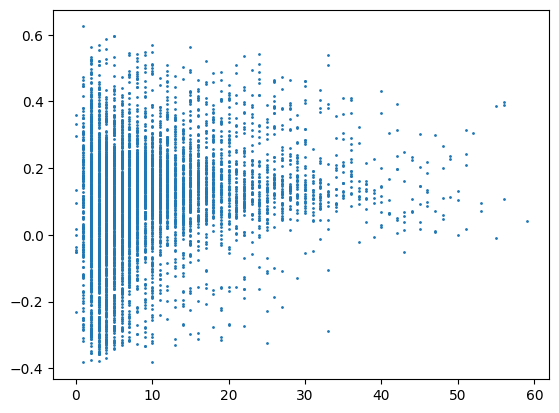

In [16]:
plt.scatter(df['DBH'], df['_mean'], s=1)
plt.show()

In [61]:
df_filtered = df[df.groupby('SPP')['SPP'].transform('size') >= 50]

In [62]:
df_filtered

,SPP,DBH,_mean,_median,_stdev,_min,_max
0,Gleditsia triacanthos,25,0.136409,0.107319,0.123564,-0.024194,0.402597
1,Fraxinus pennsylvanica,10,0.085733,0.079848,0.025145,0.046729,0.133333
3,Crataegus x Lavallei,5,0.094031,0.096774,0.026526,0.040000,0.137441
4,Ulmus pumila,20,0.136683,0.135417,0.028079,0.095436,0.184834
7,Acer platanoides,13,0.239588,0.221557,0.150083,0.015544,0.466667
...,...,...,...,...,...,...,...
7102,Zelkova serrata,11,0.124803,0.140770,0.072095,-0.035088,0.220217
7103,Zelkova serrata,9,0.175702,0.173465,0.029781,0.111765,0.249042
7104,Zelkova serrata,11,0.224157,0.226997,0.015887,0.200000,0.251852
7105,Zelkova serrata,12,0.178956,0.163121,0.038287,0.117117,0.262673


SPP
Acer platanoides           464
Gleditsia triacanthos      454
Tilia cordata              392
Pyrus calleryana           349
Platanus acerifolia        344
Zelkova serrata            312
Zelkova  species           188
Fraxinus pennsylvanica     188
Malus sylvestris           188
Fraxinus americana         161
Koelreuteria paniculata    134
Ulmus americana            127
Pinus nigra                123
Ulmus pumila               116
Stump                      110
Cercis canadensis          102
Prunus cerasifera           94
Acer campestre              81
Ginkgo biloba               76
Gymnocladus dioicus         74
Robinia pseudoacacia        69
Celtis reticulata           66
Fraxinus species            64
Crataegus x Lavallei        61
Picea pungens               58
Quercus rubra               54
Name: count, dtype: int64


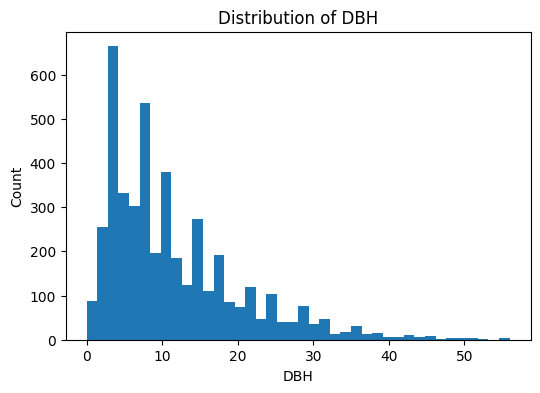

In [63]:
print(df_filtered['SPP'].value_counts())

plt.figure(figsize=(6,4))
plt.hist(df_filtered['DBH'], bins=40)
plt.xlabel("DBH")
plt.ylabel("Count")
plt.title("Distribution of DBH")
plt.show()

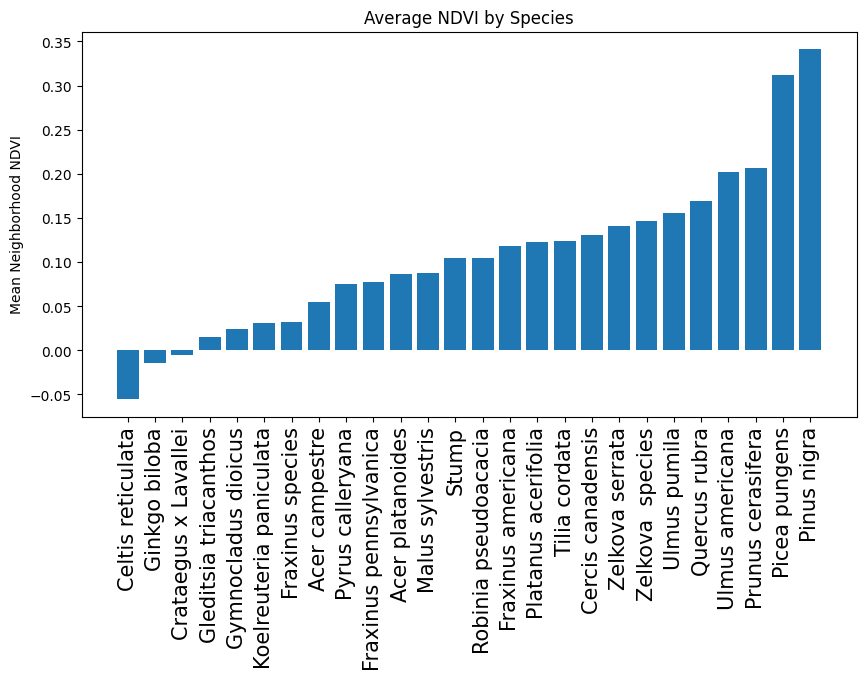

In [65]:
species_mean = df_filtered.groupby("SPP")["_mean"].mean().sort_values()

plt.figure(figsize=(10,5))
plt.bar(species_mean.index, species_mean.values)
plt.xticks(rotation=90, fontsize=15)
plt.ylabel("Mean Neighborhood NDVI")
plt.title("Average NDVI by Species")

plt.show()

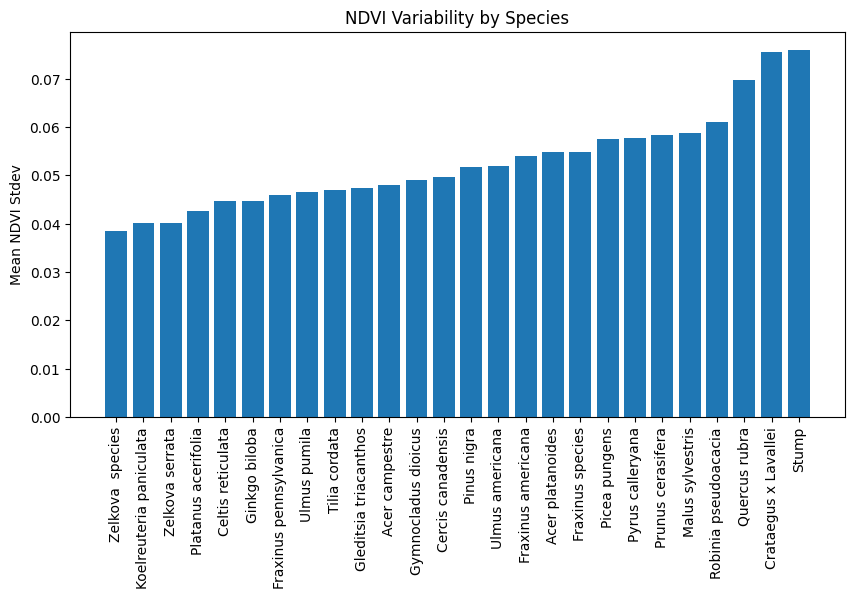

In [66]:
species_std = df_filtered.groupby("SPP")["_stdev"].mean().sort_values()

plt.figure(figsize=(10,5))
plt.bar(species_std.index, species_std.values)
plt.xticks(rotation=90)
plt.ylabel("Mean NDVI Stdev")
plt.title("NDVI Variability by Species")
plt.show()

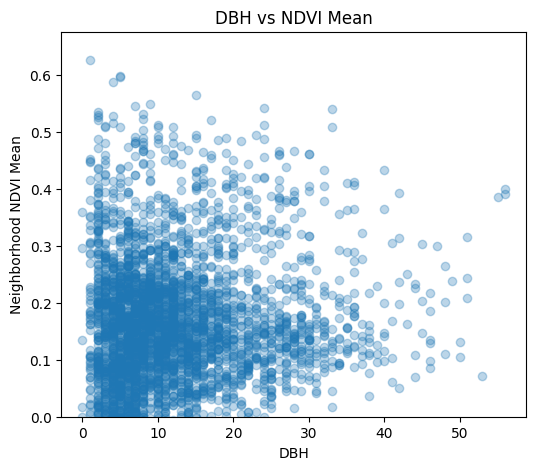

In [68]:
plt.figure(figsize=(6,5))
plt.scatter(df_filtered['DBH'], df_filtered['_mean'], alpha=0.3)
plt.xlabel("DBH")
plt.ylabel("Neighborhood NDVI Mean")
plt.ylim(bottom=0)
plt.title("DBH vs NDVI Mean")
plt.show()

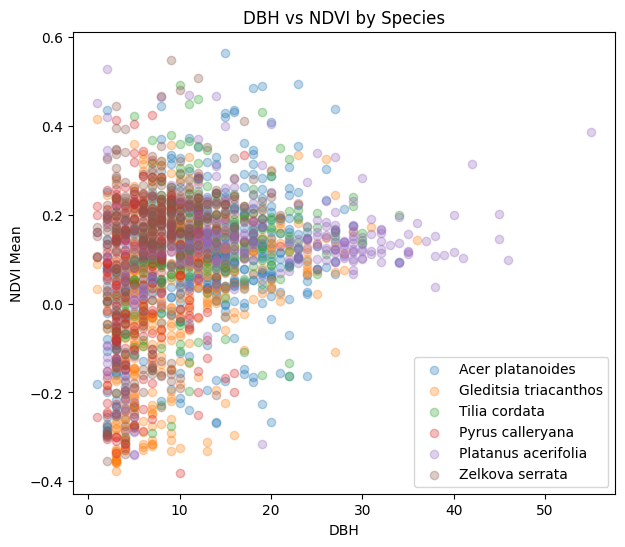

In [71]:
top_species = df_filtered['SPP'].value_counts().head(6).index

plt.figure(figsize=(7,6))

for spp in top_species:
    sub = df_filtered[df_filtered['SPP']==spp]
    plt.scatter(sub['DBH'], sub['_mean'], alpha=0.3, label=spp)

plt.xlabel("DBH")
plt.ylabel("NDVI Mean")
plt.title("DBH vs NDVI by Species")
plt.legend()
plt.show()

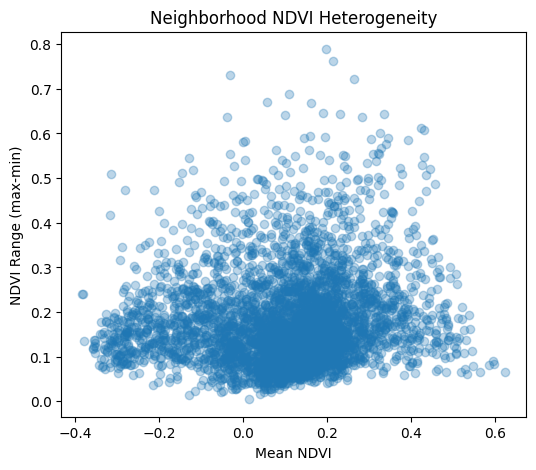

In [72]:
plt.figure(figsize=(6,5))
spread = df_filtered['_max'] - df_filtered['_min']
plt.scatter(df_filtered['_mean'], spread, alpha=0.3)

plt.xlabel("Mean NDVI")
plt.ylabel("NDVI Range (max-min)")
plt.title("Neighborhood NDVI Heterogeneity")
plt.show()

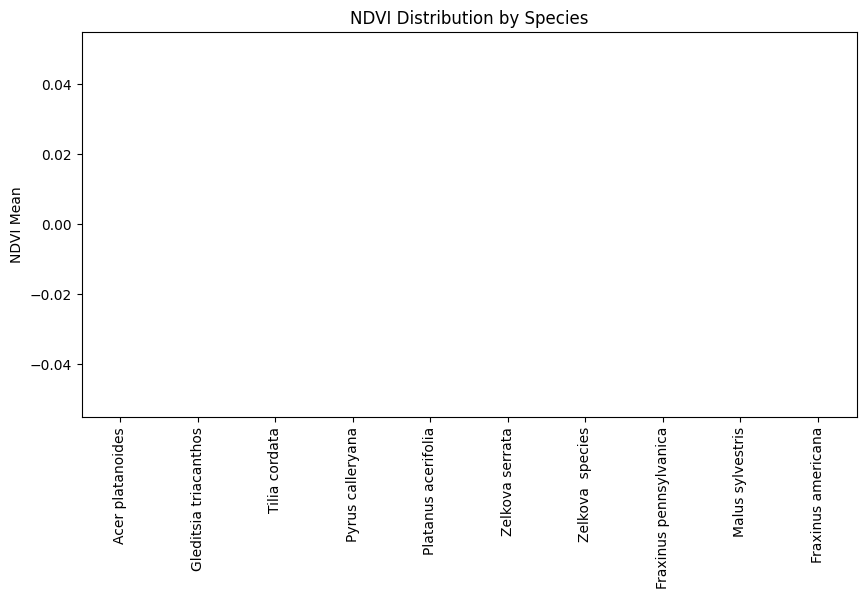

In [74]:
species = df_filtered['SPP'].value_counts().head(10).index

data = [df_filtered[df_filtered['SPP']==s]['_mean'] for s in species]

plt.figure(figsize=(10,5))
plt.boxplot(data, tick_labels=species)
plt.xticks(rotation=90)
plt.ylabel("NDVI Mean")
plt.title("NDVI Distribution by Species")
plt.show()

/tmp/ipykernel_2367/40837696.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['dbh_bin'] = pd.qcut(df_filtered['DBH'], 5)
/tmp/ipykernel_2367/40837696.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_filtered.groupby('dbh_bin')['_mean'].mean()


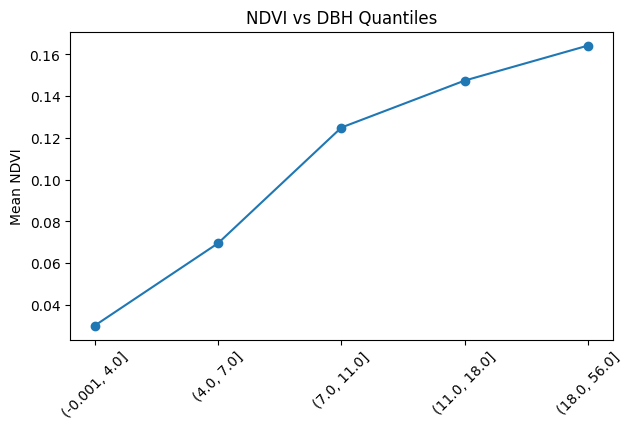

In [76]:
df_filtered['dbh_bin'] = pd.qcut(df_filtered['DBH'], 5)

grouped = df_filtered.groupby('dbh_bin')['_mean'].mean()

plt.figure(figsize=(7,4))
plt.plot(range(len(grouped)), grouped.values, marker='o')
plt.xticks(range(len(grouped)), grouped.index, rotation=45)
plt.ylabel("Mean NDVI")
plt.title("NDVI vs DBH Quantiles")
plt.show()

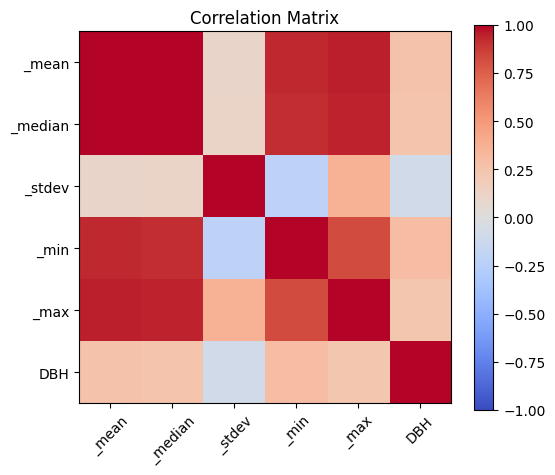

In [77]:
cols = ['_mean','_median','_stdev','_min','_max','DBH']
corr = df_filtered[cols].corr()

plt.figure(figsize=(6,5))
plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar()

plt.xticks(range(len(cols)), cols, rotation=45)
plt.yticks(range(len(cols)), cols)

plt.title("Correlation Matrix")
plt.show()

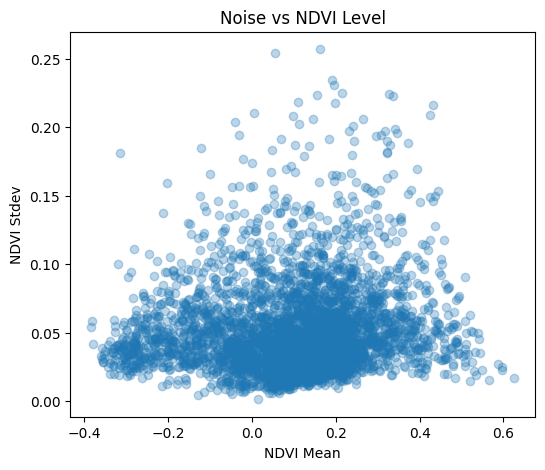

In [79]:
plt.figure(figsize=(6,5))
plt.scatter(df_filtered['_mean'], df_filtered['_stdev'], alpha=0.3)
plt.xlabel("NDVI Mean")
plt.ylabel("NDVI Stdev")
plt.title("Noise vs NDVI Level")
plt.show()

In [84]:
# Pick top 10 species by count
top_species = df_filtered['SPP'].value_counts().head(10).index

In [85]:
top_species

Index(['Acer platanoides', 'Gleditsia triacanthos', 'Tilia cordata',
       'Pyrus calleryana', 'Platanus acerifolia', 'Zelkova serrata',
       'Zelkova  species', 'Fraxinus pennsylvanica', 'Malus sylvestris',
       'Fraxinus americana'],
      dtype='object', name='SPP')

/tmp/ipykernel_2367/2241603076.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=top_species)


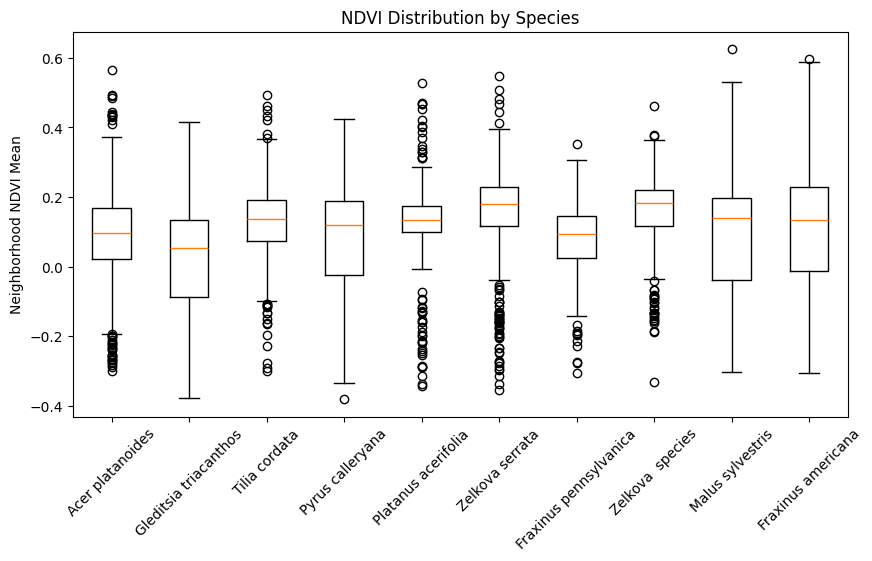

In [104]:
# Pick top 10 species by count
top_species = df['SPP'].value_counts().head(10).index

# Gather NDVI values per species
data_to_plot = [df[df['SPP'] == spp]['_mean'].values for spp in top_species]
data_to_plot = np.array([arr[~np.isnan(arr)] for arr in data_to_plot], dtype=object)


plt.figure(figsize=(10,5))
plt.boxplot(data_to_plot, labels=top_species)
plt.xticks(rotation=45)
plt.ylabel("Neighborhood NDVI Mean")
plt.title("NDVI Distribution by Species")
plt.show()

In [106]:
df['SPP'].value_counts().head(10)

,count
SPP,
Acer platanoides,464
Gleditsia triacanthos,454
Tilia cordata,392
Pyrus calleryana,349
Platanus acerifolia,344
Zelkova serrata,312
Fraxinus pennsylvanica,188
Zelkova species,188
Malus sylvestris,188
